# Saliency
Example of saliency maps from [OpenVINO](https://docs.openvino.ai/2024/notebooks/clip-language-saliency-map-with-output.html#interactive-demo-with-gradio).

Saliency Maps are one of the simplest and most intuitive methods to visualize which parts of an input image influence a neural network’s prediction the most.
They highlight which pixels (or regions) of the image the model is most sensitive to — i.e., where small changes would most affect the output.

Given a model $f(x)$ (e.g., an image classifier) and an input image $x$, a saliency map identifies which parts of $x$ contribute most strongly to the output score of a target class $c$.

Mathematically:
$$
S(x) = \frac{\partial f_c(x)}{\partial x}
$$

where:
- $f_c(x)$ is the model’s score (before softmax) for class $c$
- $\frac{\partial f_c(x)}{\partial x}$ is the gradient of that score with respect to the input pixels
- $S(x)$ is the saliency map (a matrix of the same size as the image)

Each pixel’s value in $S(x)$ measures how much a small change in that pixel would affect the output for class $c$.

## Process
1. Forward Pass:
Feed the image $x$ into the trained model to get class scores $f(x)$.

2. Select a Target Class:
Choose the class $c$ you want to explain (often the predicted class).

3. Compute the Gradient:
Calculate $\nabla_x f_c(x)$ — the derivative of the score for class $c$ with respect to the input pixels.

4. Take the Absolute Value:
The absolute value $|\nabla_x f_c(x)|$ gives the magnitude of pixel importance.

5. Visualize:
Normalize and overlay $S(x)$ on the original image as a heatmap.
Brighter or red regions = pixels most influential for the class $c$.

**Note**
- Saliency maps reveal where the model is “looking” when making a decision. For example, in an image classified as a “cat”, the saliency map may highlight the cat’s face or ears.
- It doesn’t explain why the model made that decision, only which pixels mattered most.

In [1]:
from pathlib import Path
from typing import Tuple, Union, Optional
import requests

from matplotlib import colors
import matplotlib.pyplot as plt
import numpy as np
import torch
import tqdm
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

In [2]:
model_checkpoint = "openai/clip-vit-base-patch16"

model = CLIPModel.from_pretrained(model_checkpoint).eval()
processor = CLIPProcessor.from_pretrained(model_checkpoint)

In [16]:
def get_random_crop_params(image_height: int, image_width: int, min_crop_size: int) -> Tuple[int, int, int, int]:
    crop_size = np.random.randint(min_crop_size, min(image_height, image_width))
    x = np.random.randint(image_width - crop_size + 1)
    y = np.random.randint(image_height - crop_size + 1)
    return x, y, crop_size


def get_cropped_image(im_tensor: np.array, x: int, y: int, crop_size: int) -> np.array:
    return im_tensor[y : y + crop_size, x : x + crop_size, ...]


def update_saliency_map(saliency_map: np.array, similarity: float, x: int, y: int, crop_size: int) -> None:
    saliency_map[
        y : y + crop_size,
        x : x + crop_size,
    ] += similarity


def cosine_similarity(one: Union[np.ndarray, torch.Tensor], other: Union[np.ndarray, torch.Tensor]) -> Union[np.ndarray, torch.Tensor]:
    return one @ other.T / (np.linalg.norm(one) * np.linalg.norm(other))

### Compute

Images are generater using AI. Create your own and substitute the paths.

In [17]:
n_iters = 1500
min_crop_size = 50

query = "who is the author of this painting?"
modigliani = "/Users/Flint/Pictures/AI/DrawThings/create_a_color_painting_of_a_woman_in_the_style_of_amedeo_modigliani_983775299.png"
monet = "/Users/Flint/Pictures/AI/DrawThings/create_a_color_landscape_in_the_style_of_claude_monet_745053692.png"
vangogh = "/Users/Flint/Pictures/AI/DrawThings/create_a_color_landscape_in_the_style_of_vincent_van_gogh_1018549273.png"
image_path = modigliani

image = Image.open(image_path).convert("RGB")
im_tensor = np.array(image)

x_dim, y_dim = image.size

print(f"Image of size {x_dim} X {y_dim}")

Image of size 768 X 768


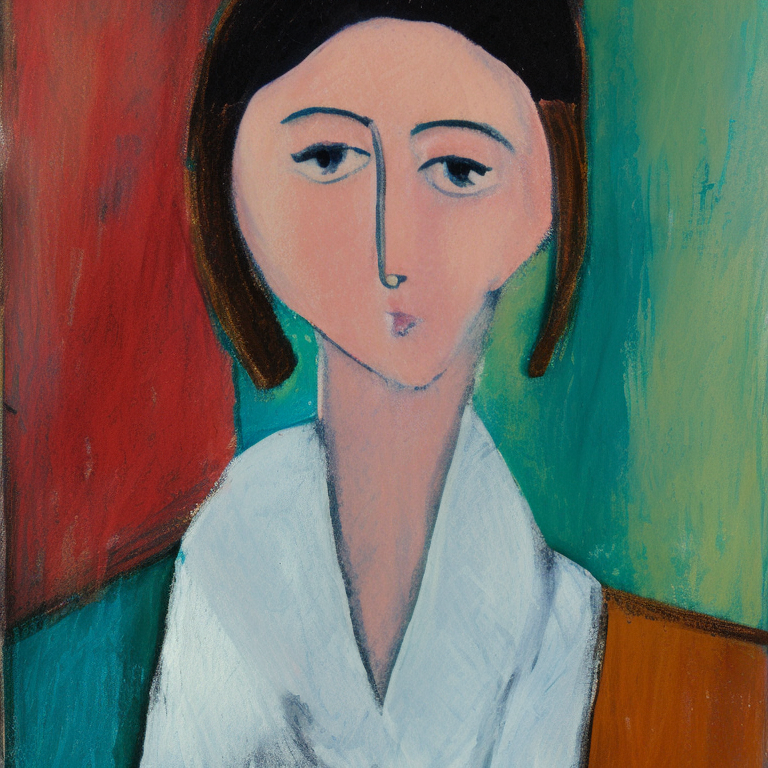

In [18]:
image

In [19]:
inputs = processor(text=[query], images=[im_tensor], return_tensors="pt")
with torch.no_grad():
    results = model(**inputs)
results.keys()

odict_keys(['logits_per_image', 'logits_per_text', 'text_embeds', 'image_embeds', 'text_model_output', 'vision_model_output'])

In [20]:
inputs = processor(text=[query], images=[im_tensor], return_tensors="pt")
with torch.no_grad():
    results = model(**inputs)
text_embeds = results.text_embeds  # save text embeddings to use them later

initial_similarity = cosine_similarity(text_embeds, results.image_embeds).item()
saliency_map = np.zeros((y_dim, x_dim))

for _ in tqdm.notebook.tqdm(range(n_iters)):
    x, y, crop_size = get_random_crop_params(y_dim, x_dim, min_crop_size)
    im_crop = get_cropped_image(im_tensor, x, y, crop_size)

    image_inputs = processor(images=[im_crop], return_tensors="pt")  # crop preprocessing
    with torch.no_grad():
        image_embeds = model.get_image_features(**image_inputs)  # calculate image embeddings only

    similarity = cosine_similarity(text_embeds, image_embeds).item() - initial_similarity
    update_saliency_map(saliency_map, similarity, x, y, crop_size)

  0%|          | 0/1500 [00:00<?, ?it/s]

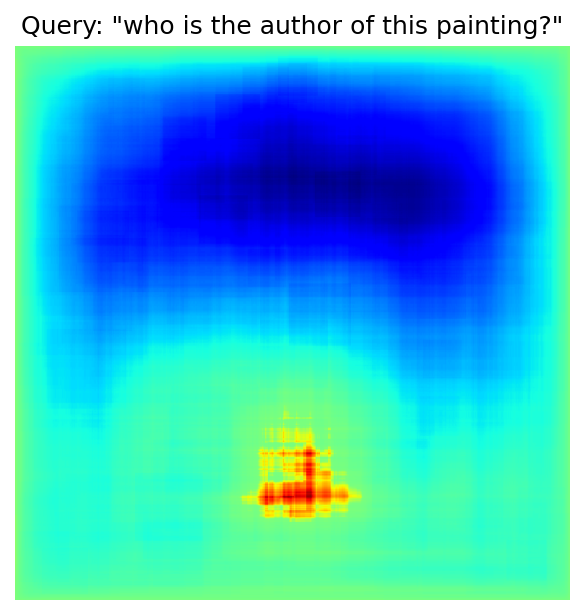

In [21]:
plt.figure(dpi=150)
plt.imshow(saliency_map, norm=colors.TwoSlopeNorm(vcenter=0), cmap="jet")
plt.title(f'Query: "{query}"')
plt.axis("off")
plt.show()

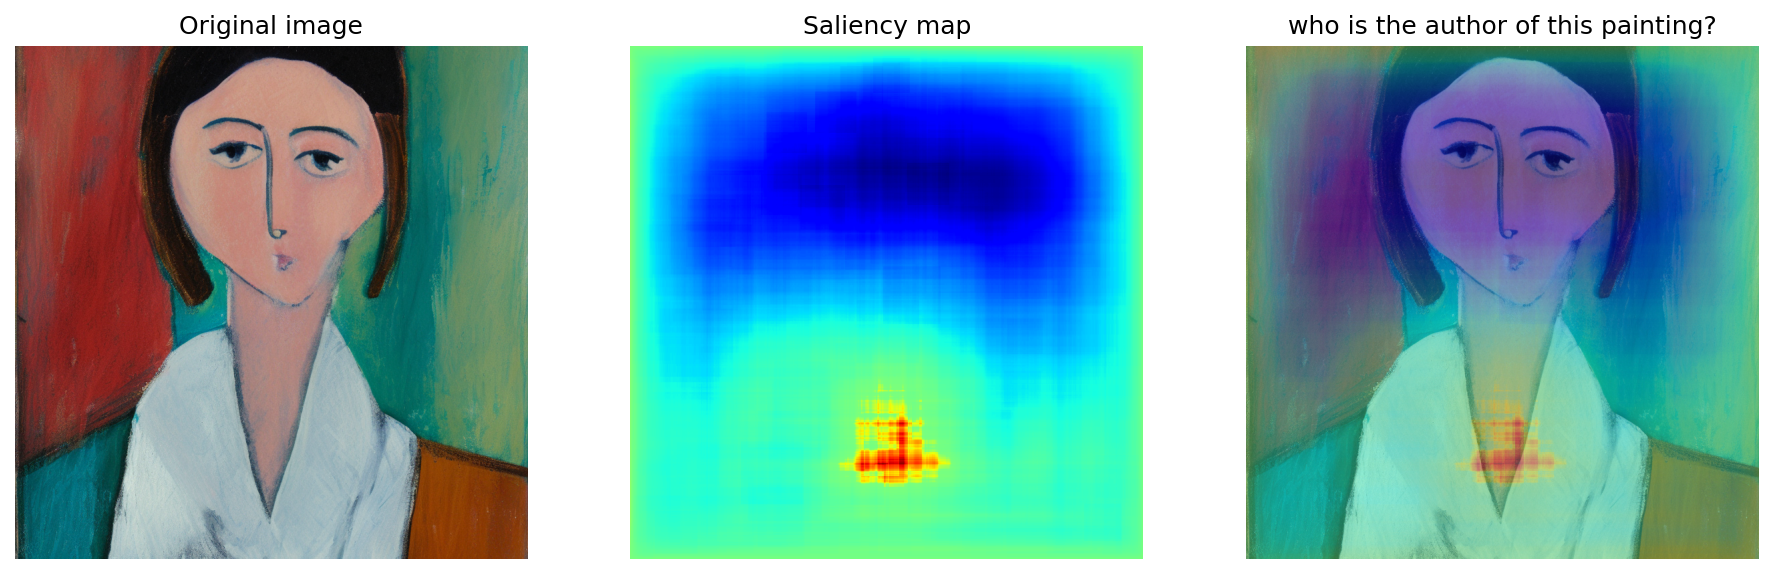

In [22]:
def plot_saliency_map(image_tensor: np.ndarray, saliency_map: np.ndarray, query: Optional[str]) -> None:
    fig = plt.figure(dpi=150)
    plt.imshow(image_tensor)
    plt.imshow(
        saliency_map,
        norm=colors.TwoSlopeNorm(vcenter=0),
        cmap="jet",
        alpha=0.4,  # make saliency map trasparent to see original picture
    )
    if query:
        plt.title(f'Query: "{query}"')
    plt.axis("off")
    plt.show()

def plot_combined(image_tensor: np.ndarray, saliency_map: np.ndarray, query: Optional[str]):
    fig, ax = plt.subplots(dpi=150, ncols=3, figsize=(15, 5))
    ax[0].imshow(image_tensor)
    ax[0].set_title("Original image")
    ax[0].axis('off')
    ax[1].imshow(saliency_map, norm=colors.TwoSlopeNorm(vcenter=0), cmap="jet")
    ax[1].set_title("Saliency map")
    ax[1].axis('off')
    ax[2].imshow(image_tensor)
    ax[2].imshow(saliency_map, norm=colors.TwoSlopeNorm(vcenter=0), cmap="jet", alpha=0.4)
    ax[2].set_title(query)
    ax[2].axis('off')


plot_combined(im_tensor, saliency_map, query)